In [10]:
import pandas as pd
import numpy as np

## Data Import

In [9]:
# Load processed dataset

df = pd.read_csv(
    "../data/processed/pri_multi_asset_etf_returns.csv",
    parse_dates=["Date"]
)

print(df.head())


# Basic validation checks

print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)


# Date consistency

print("\nDate range:")
print(df["Date"].min(), "→", df["Date"].max())

print("\nChronologically sorted:",
      df["Date"].is_monotonic_increasing)


# Descriptive statistics

display(df.describe())


# Correlation structure

return_cols = df.columns[1:]

display(df[return_cols].corr())

        Date  Treasury ETF  Technology ETF    Gold  Global Bank ETF  E MER ETF
0 2023-01-01        0.0315          0.1017  0.0554           0.0469     0.0760
1 2023-02-01       -0.0419         -0.0030 -0.0545          -0.0212    -0.0672
2 2023-03-01        0.0276          0.0908  0.0751           0.1020     0.0247
3 2023-04-01       -0.0192          0.0030  0.0109           0.0392     0.0060
4 2023-05-01       -0.0325          0.0742 -0.0161          -0.0367    -0.0202

Shape: (24, 6)

Missing values:
 Date               0
Treasury ETF       0
Technology ETF     0
Gold               0
Global Bank ETF    0
E MER ETF          0
dtype: int64

Duplicates: 0

Data types:
 Date               datetime64[us]
Treasury ETF              float64
Technology ETF            float64
Gold                      float64
Global Bank ETF           float64
E MER ETF                 float64
dtype: object

Date range:
2023-01-01 00:00:00 → 2024-12-01 00:00:00

Chronologically sorted: True


,Date,Treasury ETF,Technology ETF,Gold,Global Bank ETF,E MER ETF
count,24,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2023-12-16 10:00:00,-0.006379,0.026425,0.014287,0.024000,0.006754
min,2023-01-01 00:00:00,-0.062900,-0.052300,-0.054500,-0.049200,-0.067200
25%,2023-06-23 12:00:00,-0.035625,-0.008025,-0.013850,-0.021200,-0.038475
50%,2023-12-16 12:00:00,-0.016650,0.022700,0.021250,0.033900,0.017350
75%,2024-06-08 12:00:00,0.022025,0.059450,0.040675,0.047600,0.038025
max,2024-12-01 00:00:00,0.087100,0.104400,0.086200,0.117800,0.076000
std,NaN,0.037090,0.045682,0.038769,0.045464,0.045127


,Treasury ETF,Technology ETF,Gold,Global Bank ETF,E MER ETF
Treasury ETF,1.000000,0.617881,0.580891,0.661992,0.789680
Technology ETF,0.617881,1.000000,0.246432,0.672872,0.639053
Gold,0.580891,0.246432,1.000000,0.250293,0.547486
Global Bank ETF,0.661992,0.672872,0.250293,1.000000,0.604682
E MER ETF,0.789680,0.639053,0.547486,0.604682,1.000000


## Return Analysis

In [11]:
#Calculation of Growth Index
growth_index = 1 + df.iloc[:, 1:]

#Calculation of log returns
log_returns = np.log(1 + df.iloc[:, 1:])


In [12]:
display(growth_index.head())

,Treasury ETF,Technology ETF,Gold,Global Bank ETF,E MER ETF
0,1.0315,1.1017,1.0554,1.0469,1.0760
1,0.9581,0.9970,0.9455,0.9788,0.9328
2,1.0276,1.0908,1.0751,1.1020,1.0247
3,0.9808,1.0030,1.0109,1.0392,1.0060
4,0.9675,1.0742,0.9839,0.9633,0.9798


In [13]:
display(log_returns.head())

,Treasury ETF,Technology ETF,Gold,Global Bank ETF,E MER ETF
0,0.031014,0.096854,0.053920,0.045833,0.073250
1,-0.042803,-0.003005,-0.056041,-0.021428,-0.069564
2,0.027226,0.086911,0.072414,0.097127,0.024400
3,-0.019387,0.002996,0.010841,0.038451,0.005982
4,-0.033040,0.071576,-0.016231,-0.037390,-0.020407


In [14]:
#Calculate annualized log-returns

annual_log_returns = (
    log_returns.mean() * 12
).to_frame(name="Annualized Log Return")

display(annual_log_returns)

,Annualized Log Return
Treasury ETF,-0.084705
Technology ETF,0.301577
Gold,0.161817
Global Bank ETF,0.273278
E MER ETF,0.069147


In [15]:
# Annualized volatility

annual_volatility = (
    log_returns.std() * np.sqrt(12)
).to_frame(name="Annualized Volatility")

display(annual_volatility)

,Annualized Volatility
Treasury ETF,0.128086
Technology ETF,0.154347
Gold,0.132646
Global Bank ETF,0.153674
E MER ETF,0.156064


In [16]:
# Expected annual arithmetic returns

expected_returns = (
    annual_log_returns.squeeze()
    + (annual_volatility.squeeze() ** 2) / 2
)

expected_returns = expected_returns.to_frame(
    name="Expected Annual Return"
)

display(expected_returns)

,Expected Annual Return
Treasury ETF,-0.076502
Technology ETF,0.313489
Gold,0.170614
Global Bank ETF,0.285086
E MER ETF,0.081325


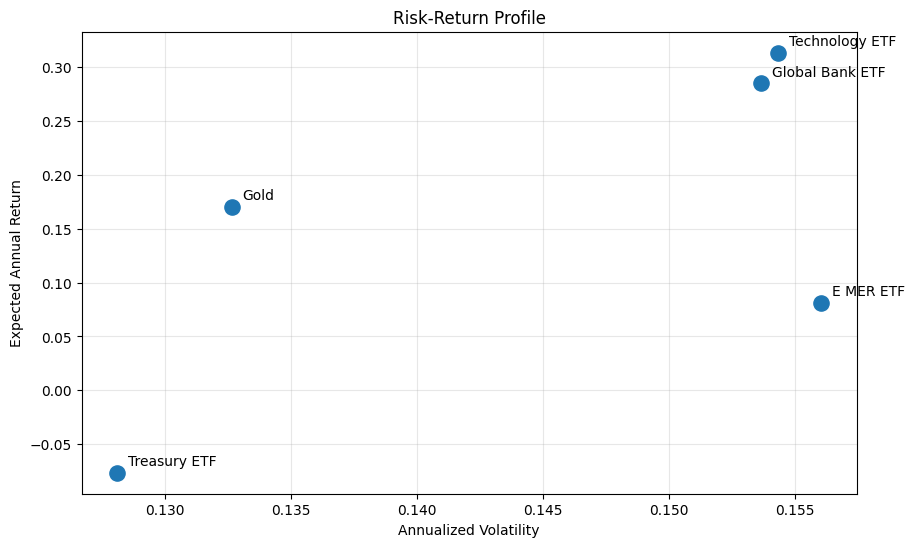

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.scatter(
    annual_volatility.squeeze(),
    expected_returns.squeeze(),
    s=120
)

# Asset labels

for asset in annual_volatility.index:

    plt.annotate(
        asset,
        (
            annual_volatility.loc[asset].values[0],
            expected_returns.loc[asset].values[0]
        ),
        xytext=(8, 5),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")

plt.title("Risk-Return Profile")

plt.grid(alpha=0.3)

plt.show()

In [20]:
# Correlation matrix

correlation_matrix = log_returns.corr()

display(correlation_matrix)

,Treasury ETF,Technology ETF,Gold,Global Bank ETF,E MER ETF
Treasury ETF,1.000000,0.620083,0.592023,0.661142,0.793244
Technology ETF,0.620083,1.000000,0.248370,0.671241,0.636094
Gold,0.592023,0.248370,1.000000,0.250598,0.554457
Global Bank ETF,0.661142,0.671241,0.250598,1.000000,0.607937
E MER ETF,0.793244,0.636094,0.554457,0.607937,1.000000


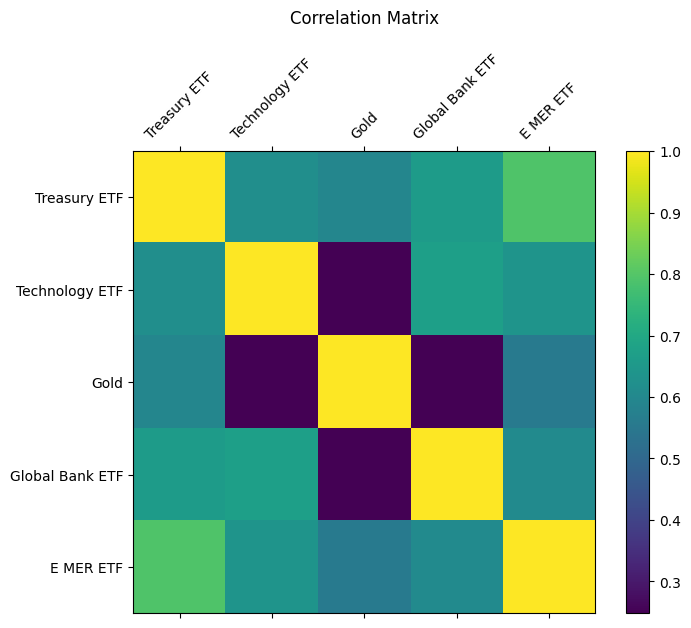

In [21]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(8, 6))

cax = ax.matshow(correlation_matrix)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

fig.colorbar(cax)

plt.title("Correlation Matrix", pad=20)

plt.show()

1. cumulative returns
2. rolling returns
3. annualized return
4. drawdowns

## Risk Analysis

1. volatility
2. rolling volatility
3. downside deviation
4. Sharpe ratio
5. Sortino ratio
6. maximum drawdown

## Correlation Structure

1. heatmaps
2. dynamic correlations
3. diversification analysis

## Portfolio Construction

1. equal-weight portfolio
2. minimum variance portfolio
3. efficient frontier
4. risk parity
5. tangency portfolio

## VaR / Expected Shortfall

## Monte Carlo Simulation

1. simulated portfolio paths
2. stress scenarios
3. volatility shocks